# Notebook 06 — Análise dos Filtros Wavelet Aprendidos (FordA)

Análise detalhada dos filtros aprendidos pela camada LearnedWaveletDWT1D_QMF:
- Extração de filtros dos modelos treinados
- Propriedades matemáticas wavelets
- Comparação com wavelets clássicas
- Análise espectral e tempo-frequência

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
import io
from pathlib import Path

import tensorflow as tf
import h5py

tf.config.set_visible_devices([], 'GPU')
import pywt
from scipy import signal as scipy_signal
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent.parent))
from config.experiment_config import RESULTS_DIR, MODELS_DIR, FORDA_CONFIG
from models.LWT.learned_wavelet_pair_qmf import LearnedWaveletPair1D_QMF
from models.LWT.learned_wavelet_dwt_qmf import LearnedWaveletDWT1D_QMF

FILTER_DIR = RESULTS_DIR / "filter_analysis"
FILTER_DIR.mkdir(parents=True, exist_ok=True)
print(f"MODELS_DIR: {MODELS_DIR}")
print(f"FILTER_DIR: {FILTER_DIR}")

I0000 00:00:1773173667.053730 2456783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


MODELS_DIR: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/saved_models
FILTER_DIR: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/filter_analysis


## 1. Carregar Modelo com Learned Wavelet

In [2]:
# Procurar o melhor modelo learned wavelet salvo
model_files = list(MODELS_DIR.glob("lw_*.keras")) + list(MODELS_DIR.glob("learned_*.keras"))
print(f"Modelos encontrados: {len(model_files)}")
for f in model_files:
    print(f"  {f.name} ({f.stat().st_size / 1024:.0f} KB)")

if model_files:
    model_path = model_files[0]
    print(f"\nCarregando: {model_path.name}")
    
    # Registrar custom objects
    custom_objects = {
        "LearnedWaveletPair1D_QMF": LearnedWaveletPair1D_QMF,
        "LearnedWaveletDWT1D_QMF": LearnedWaveletDWT1D_QMF,
    }
    
    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    model.summary()
else:
    print("Nenhum modelo learned wavelet encontrado!")
    print("Execute primeiro o notebook 04.")
    model = None

Modelos encontrados: 96
  lw_cnn_lstm_g20.keras (830 KB)
  lw_cnn_g5.keras (1851 KB)
  lw_lstm_g13.keras (1578 KB)
  lw_lstm_g11.keras (1578 KB)
  lw_cnn_lstm_g18.keras (1247 KB)
  lw_transformer_g33.keras (2302 KB)
  lw_cnn_lstm_g8.keras (830 KB)
  lw_cnn_lstm_g13.keras (1438 KB)
  lw_cnn_lstm_g3.keras (1964 KB)
  lw_lstm_g5.keras (1578 KB)
  lw_lstm_best.keras (532 KB)
  lw_transformer_best.keras (2302 KB)
  lw_transformer_g9.keras (7423 KB)
  lw_cnn_lstm_g31.keras (1964 KB)
  lw_transformer_g32.keras (2302 KB)
  lw_cnn_lstm_g9.keras (1438 KB)
  lw_cnn_g0.keras (662 KB)
  lw_cnn_g6.keras (662 KB)
  lw_cnn_lstm_g28.keras (830 KB)
  lw_cnn_lstm_g21.keras (1438 KB)
  lw_lstm_g17.keras (1578 KB)
  lw_cnn_lstm_g11.keras (1964 KB)
  lw_cnn_lstm_g1.keras (1438 KB)
  lw_cnn_g9.keras (1851 KB)
  lw_cnn_lstm_g25.keras (1438 KB)
  lw_cnn_lstm_g14.keras (1247 KB)
  lw_cnn_lstm_g29.keras (1438 KB)
  lw_cnn_g4.keras (662 KB)
  lw_cnn_g1.keras (1851 KB)
  lw_cnn_g14.keras (662 KB)
  lw_lstm_g4.kera

Model: "LearnedWavelet_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ learned_wavelet_dwt1d_qmf       │ (None, 250, 3)         │         6,340 │
│ (LearnedWaveletDWT1D_QMF)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 250, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 125, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 62, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,801 (714.07 KB)

 Trainable params: 60,869 (237.77 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 121,740 (475.55 KB)

## 2. Extração dos Filtros Aprendidos

In [6]:
def extract_filters_from_model(model):
    """Extrai filtros h e g de cada nível da camada LearnedWaveletDWT1D_QMF."""
    filters = {}
    
    for layer in model.layers:
        if isinstance(layer, LearnedWaveletDWT1D_QMF):
            print(f"Camada encontrada: {layer.name}")
            print(f"  levels: {layer.levels}")
            
            for level_idx, pair in enumerate(layer.pairs):
                # Gerar valores t
                t = pair._make_t()
                
                # scale com softplus
                scale = tf.nn.softplus(pair.raw_scale)
                translation = pair.translation
                
                # Normalizar t
                t_norm = (t - translation) / scale
                
                # Base net output
                base_out = pair.base_net(t_norm)
                
                # Low-pass h
                h = pair.low_head(base_out)
                h = tf.squeeze(h)
                h = pair._normalize_h(h)
                
                # High-pass g via QMF
                g = pair._qmf_from_h(h)
                
                h_np = h.numpy()
                g_np = g.numpy().squeeze()
                
                filters[f"level_{level_idx}"] = {
                    "h": h_np,
                    "g": g_np,
                    "scale": scale.numpy(),
                    "translation": translation.numpy(),
                }
                print(f"  Level {level_idx}: h={h_np.shape}, g={g_np.shape}, "
                      f"scale={float(scale):.4f}, translation={float(translation):.4f}")
    
    return filters

if model is not None:
    learned_filters = extract_filters_from_model(model)
    n_levels = len(learned_filters)
    print(f"\nTotal de níveis extraídos: {n_levels}")
else:
    learned_filters = {}
    n_levels = 0

Camada encontrada: learned_wavelet_dwt1d_qmf
  levels: 2
  Level 0: h=(32,), g=(32,), scale=0.6574, translation=-0.1232
  Level 1: h=(32,), g=(32,), scale=0.6835, translation=-0.0168

Total de níveis extraídos: 2


## 3. Visualização dos Filtros no Domínio do Tempo

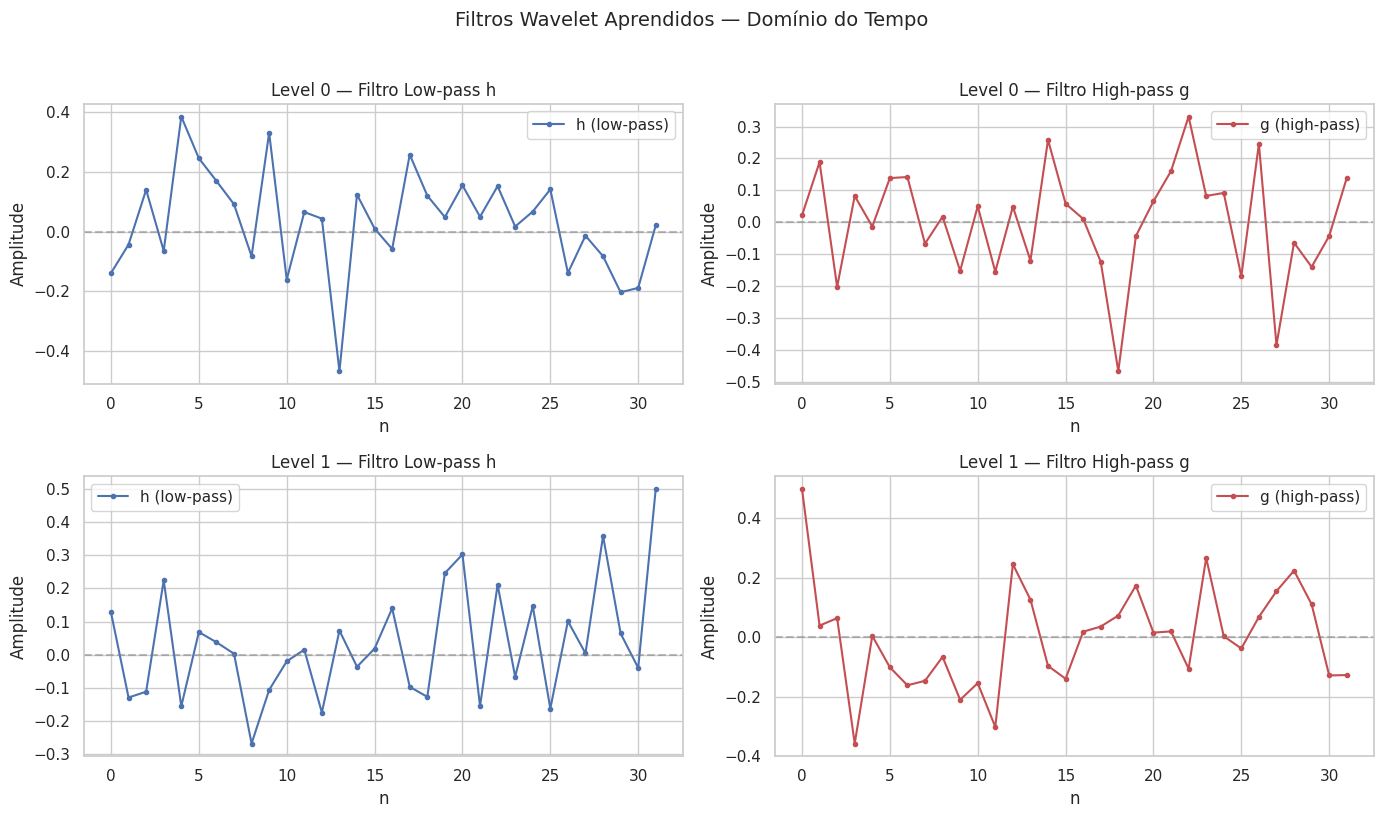

In [7]:
if learned_filters:
    fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels))
    if n_levels == 1:
        axes = axes.reshape(1, -1)

    for level_idx in range(n_levels):
        key = f"level_{level_idx}"
        h = learned_filters[key]["h"]
        g = learned_filters[key]["g"]

        axes[level_idx, 0].plot(h, "b-o", markersize=3, label="h (low-pass)")
        axes[level_idx, 0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
        axes[level_idx, 0].set_title(f"Level {level_idx} — Filtro Low-pass h")
        axes[level_idx, 0].set_xlabel("n")
        axes[level_idx, 0].set_ylabel("Amplitude")
        axes[level_idx, 0].legend()

        axes[level_idx, 1].plot(g, "r-o", markersize=3, label="g (high-pass)")
        axes[level_idx, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
        axes[level_idx, 1].set_title(f"Level {level_idx} — Filtro High-pass g")
        axes[level_idx, 1].set_xlabel("n")
        axes[level_idx, 1].set_ylabel("Amplitude")
        axes[level_idx, 1].legend()

    plt.suptitle("Filtros Wavelet Aprendidos — Domínio do Tempo", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FILTER_DIR / "filters_time_domain.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Propriedade: Admissibilidade

In [8]:
def check_admissibility(g):
    """Verifica condição de admissibilidade: soma(g) ≈ 0."""
    g_sum = np.sum(g)
    return {
        "sum_g": g_sum,
        "abs_sum_g": np.abs(g_sum),
        "is_admissible": np.abs(g_sum) < 0.01
    }

if learned_filters:
    print("ANÁLISE DE ADMISSIBILIDADE:")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_admissibility(filt["g"])
        status = "✓ ADMISSÍVEL" if res["is_admissible"] else "✗ NÃO ADMISSÍVEL"
        print(f"  {key}: sum(g) = {res['sum_g']:.6f}  |sum(g)| = {res['abs_sum_g']:.6f}  {status}")

ANÁLISE DE ADMISSIBILIDADE:
--------------------------------------------------
  level_0: sum(g) = -0.020831  |sum(g)| = 0.020831  ✗ NÃO ADMISSÍVEL
  level_1: sum(g) = 0.009048  |sum(g)| = 0.009048  ✓ ADMISSÍVEL


## 5. Propriedade: Normalização

In [9]:
def check_normalization(h, g):
    """Verifica normalização L2: ||h||_2 ≈ 1 e sum(h) ≈ √2."""
    h_l2 = np.linalg.norm(h)
    g_l2 = np.linalg.norm(g)
    h_sum = np.sum(h)
    return {
        "h_l2_norm": h_l2,
        "g_l2_norm": g_l2,
        "h_sum": h_sum,
        "h_sum_target": np.sqrt(2),
        "h_sum_error": np.abs(h_sum - np.sqrt(2)),
        "h_l2_ok": np.abs(h_l2 - 1.0) < 0.05,
        "h_sum_ok": np.abs(h_sum - np.sqrt(2)) < 0.1,
    }

if learned_filters:
    print("ANÁLISE DE NORMALIZAÇÃO:")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_normalization(filt["h"], filt["g"])
        l2_status = "✓" if res["h_l2_ok"] else "✗"
        sum_status = "✓" if res["h_sum_ok"] else "✗"
        print(f"  {key}:")
        print(f"    ||h||_2 = {res['h_l2_norm']:.6f} (target: 1.0) {l2_status}")
        print(f"    ||g||_2 = {res['g_l2_norm']:.6f} (target: 1.0)")
        print(f"    sum(h) = {res['h_sum']:.6f} (target: {res['h_sum_target']:.6f}) {sum_status}")

ANÁLISE DE NORMALIZAÇÃO:
--------------------------------------------------
  level_0:
    ||h||_2 = 0.968620 (target: 1.0) ✓
    ||g||_2 = 0.968620 (target: 1.0)
    sum(h) = 1.000000 (target: 1.414214) ✗
  level_1:
    ||h||_2 = 0.978540 (target: 1.0) ✓
    ||g||_2 = 0.978540 (target: 1.0)
    sum(h) = 1.000000 (target: 1.414214) ✗


## 6. Propriedade: QMF (Quadrature Mirror Filter)

ANÁLISE QMF (Quadrature Mirror Filter):
--------------------------------------------------
  level_0: L2 error = 0.00000000, max error = 0.00000000  ✓ QMF
  level_1: L2 error = 0.00000000, max error = 0.00000000  ✓ QMF


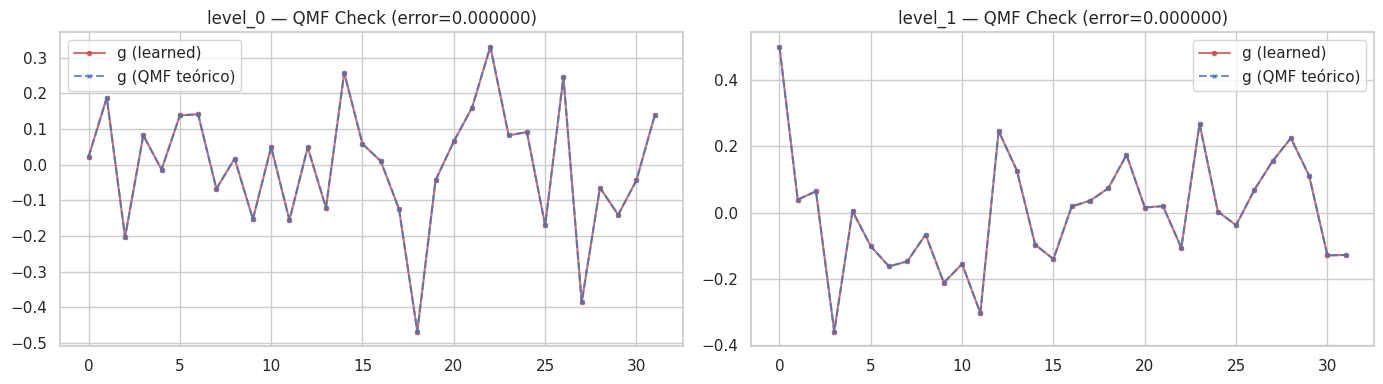

In [10]:
def check_qmf(h, g):
    """Verifica relação QMF: g[n] = (-1)^n * h[L-1-n]."""
    L = len(h)
    g_expected = np.array([(-1)**n * h[L - 1 - n] for n in range(L)])
    error = np.linalg.norm(g - g_expected)
    max_error = np.max(np.abs(g - g_expected))
    return {
        "g_expected": g_expected,
        "l2_error": error,
        "max_error": max_error,
        "is_qmf": error < 0.01
    }

if learned_filters:
    print("ANÁLISE QMF (Quadrature Mirror Filter):")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_qmf(filt["h"], filt["g"])
        status = "✓ QMF" if res["is_qmf"] else "✗ NÃO QMF"
        print(f"  {key}: L2 error = {res['l2_error']:.8f}, max error = {res['max_error']:.8f}  {status}")

    # Visualizar QMF
    fig, axes = plt.subplots(1, n_levels, figsize=(7 * n_levels, 4))
    if n_levels == 1:
        axes = [axes]
    for i, (key, filt) in enumerate(learned_filters.items()):
        res = check_qmf(filt["h"], filt["g"])
        axes[i].plot(filt["g"], "r-o", markersize=3, label="g (learned)", alpha=0.8)
        axes[i].plot(res["g_expected"], "b--x", markersize=3, label="g (QMF teórico)", alpha=0.8)
        axes[i].set_title(f"{key} — QMF Check (error={res['l2_error']:.6f})")
        axes[i].legend()
    plt.tight_layout()
    plt.savefig(FILTER_DIR / "qmf_check.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Propriedade: Reconstrução Perfeita

In [ ]:
def check_perfect_reconstruction(h, g):
    """Verifica reconstrução perfeita: |H(w)|^2 + |G(w)|^2 = 1."""
    N = max(512, len(h) * 8)
    H = np.fft.fft(h, N)
    G = np.fft.fft(g, N)
    power_sum = np.abs(H)**2 + np.abs(G)**2
    error = np.max(np.abs(power_sum - 2.0))  # For CQF: sum = 2
    return {
        "power_sum": power_sum,
        "mean_power": np.mean(power_sum),
        "max_deviation": error,
        "is_pr": error < 0.1
    }

if learned_filters:
    print("ANÁLISE DE RECONSTRUÇÃO PERFEITA:")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_perfect_reconstruction(filt["h"], filt["g"])
        status = "✓ PR" if res["is_pr"] else "✗ NOT PR"
        print(f"  {key}: mean(|H|²+|G|²) = {res['mean_power']:.6f}, "
              f"max_dev = {res['max_deviation']:.6f}  {status}")

    # Visualizar power complementarity
    fig, axes = plt.subplots(1, n_levels, figsize=(7 * n_levels, 4))
    if n_levels == 1:
        axes = [axes]
    for i, (key, filt) in enumerate(learned_filters.items()):
        res = check_perfect_reconstruction(filt["h"], filt["g"])
        freq = np.linspace(0, 1, len(res["power_sum"]))
        axes[i].plot(freq, res["power_sum"], "g-", label="|H|²+|G|²")
        axes[i].axhline(y=2.0, color="red", linestyle="--", label="Target=2", alpha=0.7)
        axes[i].set_title(f"{key} — Power Complementarity")
        axes[i].set_xlabel("Freq. normalizada")
        axes[i].legend()
    plt.tight_layout()
    plt.savefig(FILTER_DIR / "perfect_reconstruction.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Propriedade: Ortogonalidade

In [ ]:
def check_orthogonality(h):
    """Verifica ortogonalidade: autocorrelação em shifts pares ≈ 0."""
    L = len(h)
    autocorr = np.correlate(h, h, mode="full")
    center = len(autocorr) // 2
    # Pegar shifts pares (exceto zero)
    even_shifts = autocorr[center::2][1:]  # shift 2, 4, 6, ...
    max_even = np.max(np.abs(even_shifts)) if len(even_shifts) > 0 else 0.0
    return {
        "autocorrelation": autocorr,
        "even_shift_values": even_shifts,
        "max_even_shift": max_even,
        "is_orthogonal": max_even < 0.01
    }

if learned_filters:
    print("ANÁLISE DE ORTOGONALIDADE:")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_orthogonality(filt["h"])
        status = "✓ ORTOGONAL" if res["is_orthogonal"] else "✗ NÃO ORTOGONAL"
        print(f"  {key}: max |autocorr(2k)| = {res['max_even_shift']:.8f}  {status}")

## 9. Resposta em Frequência

In [ ]:
def compute_frequency_response(h, g, N=512):
    """Calcula resposta em frequência dos filtros."""
    H = np.fft.fft(h, N)
    G = np.fft.fft(g, N)
    freq = np.fft.fftfreq(N)
    pos = freq >= 0
    return {
        "freq": freq[pos],
        "H_mag": np.abs(H[pos]),
        "G_mag": np.abs(G[pos]),
        "H_phase": np.angle(H[pos]),
        "G_phase": np.angle(G[pos]),
    }

if learned_filters:
    fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels))
    if n_levels == 1:
        axes = axes.reshape(1, -1)

    for i, (key, filt) in enumerate(learned_filters.items()):
        resp = compute_frequency_response(filt["h"], filt["g"])

        # Magnitude
        axes[i, 0].plot(resp["freq"], resp["H_mag"], "b-", label="|H(ω)|")
        axes[i, 0].plot(resp["freq"], resp["G_mag"], "r-", label="|G(ω)|")
        axes[i, 0].set_title(f"{key} — Magnitude")
        axes[i, 0].set_xlabel("Freq. normalizada")
        axes[i, 0].set_ylabel("Magnitude")
        axes[i, 0].legend()

        # Fase
        axes[i, 1].plot(resp["freq"], resp["H_phase"], "b-", label="∠H(ω)")
        axes[i, 1].plot(resp["freq"], resp["G_phase"], "r-", label="∠G(ω)")
        axes[i, 1].set_title(f"{key} — Fase")
        axes[i, 1].set_xlabel("Freq. normalizada")
        axes[i, 1].set_ylabel("Fase (rad)")
        axes[i, 1].legend()

    plt.suptitle("Resposta em Frequência — Filtros Aprendidos", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FILTER_DIR / "frequency_response.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Propriedade: Momentos de Anulação

In [ ]:
def check_vanishing_moments(g, max_k=6):
    """Verifica momentos de anulação: sum(n^k * g[n]) ≈ 0 para k = 0, ..., K-1."""
    L = len(g)
    n = np.arange(L, dtype=float)
    moments = {}
    n_vanishing = 0
    for k in range(max_k):
        m_k = np.sum((n ** k) * g)
        moments[k] = m_k
        if np.abs(m_k) < 0.05:
            n_vanishing = k + 1
        else:
            break
    return {"moments": moments, "n_vanishing": n_vanishing}

if learned_filters:
    print("ANÁLISE DE MOMENTOS DE ANULAÇÃO:")
    print("-" * 50)
    for key, filt in learned_filters.items():
        res = check_vanishing_moments(filt["g"])
        print(f"  {key}: {res['n_vanishing']} momentos de anulação")
        for k, val in res["moments"].items():
            vanish = "✓" if np.abs(val) < 0.05 else "✗"
            print(f"    k={k}: sum(n^{k}*g[n]) = {val:.8f} {vanish}")

## 11. Comparação com Wavelets Clássicas

In [ ]:
def get_classical_filters():
    """Retorna filtros de wavelets clássicas via pywt."""
    classical = {}
    for wname in ["db2", "db4", "sym4", "coif1"]:
        wav = pywt.Wavelet(wname)
        classical[wname] = {"h": np.array(wav.dec_lo), "g": np.array(wav.dec_hi)}
    return classical

def compare_with_classical(learned_h, classical_filters):
    """Calcula correlação entre filtro aprendido e filtros clássicos."""
    results = {}
    for name, cf in classical_filters.items():
        # Resample para mesmo tamanho
        target_len = len(learned_h)
        if len(cf["h"]) != target_len:
            resampled = scipy_signal.resample(cf["h"], target_len)
        else:
            resampled = cf["h"]
        corr, _ = pearsonr(learned_h, resampled)
        results[name] = {"correlation": corr, "abs_correlation": np.abs(corr)}
    return results

if learned_filters:
    classical = get_classical_filters()
    print("COMPARAÇÃO COM WAVELETS CLÁSSICAS:")
    print("-" * 60)
    for key, filt in learned_filters.items():
        print(f"\n  {key}:")
        comp = compare_with_classical(filt["h"], classical)
        best_name, best_corr = None, 0.0
        for name, res in comp.items():
            print(f"    vs {name}: corr = {res['correlation']:.4f} (|corr| = {res['abs_correlation']:.4f})")
            if res["abs_correlation"] > best_corr:
                best_corr = res["abs_correlation"]
                best_name = name
        print(f"    >> Mais similar a: {best_name} (|r|={best_corr:.4f})")

## 12. Comparação Espectral com Wavelets Clássicas

In [ ]:
if learned_filters:
    classical = get_classical_filters()
    N_fft = 512

    fig, axes = plt.subplots(n_levels, 1, figsize=(12, 5 * n_levels))
    if n_levels == 1:
        axes = [axes]

    for i, (key, filt) in enumerate(learned_filters.items()):
        H_learned = np.abs(np.fft.fft(filt["h"], N_fft))
        freq = np.fft.fftfreq(N_fft)
        pos = freq >= 0

        axes[i].plot(freq[pos], H_learned[pos], "k-", linewidth=2, label="Learned", alpha=0.9)

        colors = {"db2": "#2196F3", "db4": "#FF9800", "sym4": "#4CAF50", "coif1": "#E91E63"}
        for name, cf in classical.items():
            H_cl = np.abs(np.fft.fft(cf["h"], N_fft))
            axes[i].plot(freq[pos], H_cl[pos], "--", color=colors.get(name, "gray"),
                        label=name, alpha=0.7)

        axes[i].set_title(f"{key} — Spectral Comparison |H(ω)|")
        axes[i].set_xlabel("Freq. normalizada")
        axes[i].set_ylabel("Magnitude")
        axes[i].legend()

    plt.tight_layout()
    plt.savefig(FILTER_DIR / "spectral_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. Produto Tempo-Frequência (Incerteza de Heisenberg)

In [ ]:
def time_frequency_product(h):
    """Calcula produto tempo-frequência (princípio da incerteza)."""
    h2 = h ** 2
    h2_sum = np.sum(h2)
    if h2_sum == 0:
        return {"delta_t": np.inf, "delta_f": np.inf, "product": np.inf}
    h2_norm = h2 / h2_sum
    
    n = np.arange(len(h), dtype=float)
    mean_t = np.sum(n * h2_norm)
    var_t = np.sum((n - mean_t)**2 * h2_norm)
    delta_t = np.sqrt(var_t)
    
    H = np.fft.fft(h, 1024)
    H2 = np.abs(H)**2
    H2_sum = np.sum(H2)
    H2_norm = H2 / H2_sum
    freq = np.fft.fftfreq(1024)
    mean_f = np.sum(freq * H2_norm)
    var_f = np.sum((freq - mean_f)**2 * H2_norm)
    delta_f = np.sqrt(var_f)
    
    return {"delta_t": delta_t, "delta_f": delta_f, "product": delta_t * delta_f}

if learned_filters:
    classical = get_classical_filters()
    print("PRODUTO TEMPO-FREQUÊNCIA (ΔtΔf ≥ 1/4π):")
    print("-" * 60)
    lower_bound = 1.0 / (4 * np.pi)
    print(f"  Limite inferior teórico: {lower_bound:.6f}\n")

    print("  Filtros Aprendidos:")
    for key, filt in learned_filters.items():
        res = time_frequency_product(filt["h"])
        print(f"    {key}: Δt={res['delta_t']:.4f}, Δf={res['delta_f']:.4f}, "
              f"ΔtΔf={res['product']:.6f}")

    print("\n  Wavelets Clássicas:")
    for name, cf in classical.items():
        res = time_frequency_product(cf["h"])
        print(f"    {name}: Δt={res['delta_t']:.4f}, Δf={res['delta_f']:.4f}, "
              f"ΔtΔf={res['product']:.6f}")

## 14. Parâmetros de Escala e Translação

In [ ]:
if learned_filters:
    print("PARÂMETROS DE ESCALA E TRANSLAÇÃO APRENDIDOS:")
    print("-" * 50)
    scales = []
    translations = []
    for key, filt in learned_filters.items():
        s = float(filt["scale"])
        t = float(filt["translation"])
        scales.append(s)
        translations.append(t)
        print(f"  {key}: scale={s:.6f}, translation={t:.6f}")

    if n_levels > 1:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        levels = range(n_levels)
        axes[0].bar(levels, scales, color="#2196F3", alpha=0.8)
        axes[0].set_xlabel("Level")
        axes[0].set_ylabel("Scale (softplus)")
        axes[0].set_title("Escala por Nível")
        axes[1].bar(levels, translations, color="#FF9800", alpha=0.8)
        axes[1].set_xlabel("Level")
        axes[1].set_ylabel("Translation")
        axes[1].set_title("Translação por Nível")
        plt.tight_layout()
        plt.savefig(FILTER_DIR / "scale_translation.png", dpi=150, bbox_inches="tight")
        plt.show()

## 15. Energia por Sub-banda na Decomposição

In [ ]:
if model is not None:
    # Carregar dados de teste 
    try:
        from config.experiment_config import DATA_DIR
        X_test = np.load(DATA_DIR / "X_test.npy")
        print(f"X_test shape: {X_test.shape}")

        # Extrair camada wavelet e decompor um batch
        wavelet_layer = None
        for layer in model.layers:
            if isinstance(layer, LearnedWaveletDWT1D_QMF):
                wavelet_layer = layer
                break

        if wavelet_layer is not None:
            sample = X_test[:100]
            if sample.ndim == 2:
                sample = sample[..., np.newaxis]
            sample_tf = tf.constant(sample, dtype=tf.float32)
            decomp = wavelet_layer(sample_tf)
            
            print(f"Decomposed shape: {decomp.shape}")
            n_channels = decomp.shape[-1]
            energies = []
            for ch in range(n_channels):
                ch_data = decomp[:, :, ch].numpy()
                e = np.mean(ch_data ** 2)
                energies.append(e)
                print(f"  Channel {ch}: mean energy = {e:.6f}")

            fig, ax = plt.subplots(figsize=(8, 5))
            labels = [f"Ch{i}" for i in range(n_channels)]
            ax.bar(labels, energies, color=plt.cm.viridis(np.linspace(0.2, 0.8, n_channels)))
            ax.set_xlabel("Sub-banda / Canal")
            ax.set_ylabel("Energia Média")
            ax.set_title("Energia Média por Sub-banda (FordA)")
            plt.tight_layout()
            plt.savefig(FILTER_DIR / "energy_per_subband.png", dpi=150, bbox_inches="tight")
            plt.show()
    except Exception as e:
        print(f"Erro ao carregar dados: {e}")

## 16. Diversidade entre Níveis

In [ ]:
if learned_filters and n_levels > 1:
    print("DIVERSIDADE ENTRE NÍVEIS:")
    print("-" * 50)

    # Correlação entre filtros h de diferentes níveis
    filter_keys = sorted(learned_filters.keys())
    corr_matrix = np.zeros((n_levels, n_levels))
    for i in range(n_levels):
        for j in range(n_levels):
            hi = learned_filters[filter_keys[i]]["h"]
            hj = learned_filters[filter_keys[j]]["h"]
            if len(hi) == len(hj):
                corr, _ = pearsonr(hi, hj)
                corr_matrix[i, j] = corr
            else:
                hj_r = scipy_signal.resample(hj, len(hi))
                corr, _ = pearsonr(hi, hj_r)
                corr_matrix[i, j] = corr

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
                xticklabels=[f"L{i}" for i in range(n_levels)],
                yticklabels=[f"L{i}" for i in range(n_levels)],
                vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlação entre Filtros h de Diferentes Níveis")
    plt.tight_layout()
    plt.savefig(FILTER_DIR / "cross_level_correlation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nMatriz de correlação:")
    print(pd.DataFrame(corr_matrix,
                       index=[f"Level_{i}" for i in range(n_levels)],
                       columns=[f"Level_{i}" for i in range(n_levels)]).to_string())
elif n_levels <= 1:
    print("Análise de diversidade requer mais de 1 nível.")

## 17. Relatório Consolidado

In [ ]:
if learned_filters:
    print("\n" + "=" * 80)
    print("RELATÓRIO CONSOLIDADO — Filtros Wavelet Aprendidos (FordA)")
    print("=" * 80)

    classical = get_classical_filters()
    summary_rows = []
    for key, filt in learned_filters.items():
        h, g = filt["h"], filt["g"]
        adm = check_admissibility(g)
        norm = check_normalization(h, g)
        qmf = check_qmf(h, g)
        pr = check_perfect_reconstruction(h, g)
        orth = check_orthogonality(h)
        vm = check_vanishing_moments(g)
        tfp = time_frequency_product(h)
        comp = compare_with_classical(h, classical)
        best_cl = max(comp.items(), key=lambda x: x[1]["abs_correlation"])

        summary_rows.append({
            "Level": key,
            "Filter Length": len(h),
            "Admissible": "✓" if adm["is_admissible"] else "✗",
            "||h||_2": f"{norm['h_l2_norm']:.4f}",
            "QMF": "✓" if qmf["is_qmf"] else "✗",
            "Perfect Recon.": "✓" if pr["is_pr"] else "✗",
            "Orthogonal": "✓" if orth["is_orthogonal"] else "✗",
            "Vanish. Moments": vm["n_vanishing"],
            "ΔtΔf": f"{tfp['product']:.6f}",
            "Closest Wavelet": f"{best_cl[0]} (|r|={best_cl[1]['abs_correlation']:.3f})",
            "Scale": f"{float(filt['scale']):.4f}",
            "Translation": f"{float(filt['translation']):.4f}",
        })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(FILTER_DIR / "filter_properties_summary.csv", index=False)
    print(f"\nResumo salvo em {FILTER_DIR / 'filter_properties_summary.csv'}")

## 18. Conclusão

In [ ]:
print("\n" + "=" * 80)
print("ANÁLISE DE FILTROS CONCLUÍDA!")
print("=" * 80)
print(f"\nTodos os resultados salvos em: {FILTER_DIR}")
print("\nArquivos gerados:")
for f in sorted(FILTER_DIR.glob("*")):
    print(f"  {f.name}")

print("\n--- Principais Observações ---")
if learned_filters:
    for key in learned_filters:
        filt = learned_filters[key]
        adm = check_admissibility(filt["g"])
        qmf = check_qmf(filt["h"], filt["g"])
        print(f"  {key}: Admissível={adm['is_admissible']}, QMF={qmf['is_qmf']}")